# **Vocal Isolation for Music (Source Separation)**


## **Abstract**

Vocal extraction from instrumentals in music is an advanced in the field of audio signal processing. The operation, generally known as music source separation, enables various uses such as remixing, karaoke recording, music analysis, and audio restoration. The objective is to demix different sources of sound—such as vocals, drums, bass, and random instruments—from a mixed audio, which must be strongly modelled as such elements intersect with one another in both the time and frequency domains.

Within this research, I investigate state-of-the-art source separation techniques using time-domain based audio separation networks, particularly based on masking-type methods. I train and evaluate Conv-TasNet, an effective convolutional time-domain audio separation network that is used for end-to-end source separation of speech and music. The network is trained to isolate vocals and other primary instrumental stems, i.e., drums, bass, and miscellaneous background. By using the strengths of Conv-TasNet's encoder-masker-decoder architecture, I aim to achieve high-quality separation performance and investigate its practical use in audio processing applications in the real world.

## **Introduction**

The problem addressed in this work is music source separation, which involves decomposing a mixed audio track into its original components or "stems"—such as vocals, drums, bass, and other instruments. This task is important because it has widespread applications in music production, remixing, karaoke, audio editing, and music education, where having access to isolated sources enhances creativity, analysis, and interactivity. It also aligns with cognitive studies of how humans perceptually separate sound sources, a phenomenon known as the "cocktail party effect."

However, this problem is challenging due to several factors. First, music is composed of harmonically rich and overlapping sounds that make separation inherently difficult. Second, many high-performing models rely on spectrogram-based approaches, which convert audio into a time-frequency representation. These methods often struggle with loss of phase information and blurring of transient events, especially in percussive sounds like drums. While waveform-based models offer a promising alternative by directly modeling raw audio signals, previous attempts (e.g., Wave-U-Net) have generally underperformed compared to spectrogram-based methods. Furthermore, audio artifacts, source bleeding, and limited labeled datasets pose additional challenges for building robust, high-fidelity separation systems.

### **Related Works**

Music source separation methods are traditionally categorized into spectrogram-based and waveform-based models. Spectrogram-based models include architectures like Open-Unmix, a biLSTM with fully connected layers that predicts a mask on the input spectrogram, and D3Net, which employs dilated convolutional blocks with dense connections. More recently, models have adopted complex spectrograms as both input and output, providing a richer representation and removing the constraint of the Ideal Ratio Mask. The current state-of-the-art in this category is Band-Split RNN, which combines this complex spectrogram approach with multiple dual-path RNNs, each specialized for a specific frequency band, achieving 8.9 dB SDR on the MUSDB dataset.

Waveform-based approaches began with Wave-U-Net, which laid the groundwork for Demucs, a time-domain U-Net with a biLSTM between the encoder and decoder. A more recent trend is to leverage both time and frequency domains, either through model blending (e.g., KUIELAB-MDX-Net) or hybrid architectures like Hybrid Demucs, which features a bi-U-Net structure with a shared backbone. Hybrid Demucs achieved first place in the most recent MDX Music Separation Challenge, though it has since been outperformed by Band-Split RNN.

More recently, a new architecture inspired by Demucs has emerged: Hybrid Transformer Demucs. It incorporates attention mechanisms to enhance performance across sources. While it can outperform Band-Split RNN in some scenarios, Band-Split RNN still shows superior results in vocal separation.

### **Approach Overview**

In this work, I adopt Conv-TasNet for the task of music source separation. Conv-TasNet is a deep learning architecture that performs end-to-end audio separation directly in the time domain, operating on raw waveforms rather than spectrograms. This design allows the model to preserve phase information and enables low-latency and high-quality separation. To train and evaluate the model, I use the MusDB18 dataset, a widely used benchmark for music source separation that provides professionally mixed audio tracks along with isolated stems.

## **Methodology**

### **Dataset**

I use the MusDB18 dataset, which has a total size of approximately 4.4 GB and contains 150 music tracks. Of these, 100 are designated for training and 50 for testing. For the validation set, I randomly selected 20% of the training tracks, resulting in 80 tracks for training, 20 for validation, and 50 for testing.

Each music file is initially provided as a single MP4 file, which I convert into five WAV files, as my model processes WAV files as input. I cover most of the dataset preprocessing steps, including handling issues related to sample rate and chunking, in [Section "Experimental Setup"](Project.ipynb#experimental-setup). Additionally, to improve the model's robustness and generalization, I apply on-the-fly augmentation techniques, such as speed changing and shifting, alongside chunking.

### **Model**

As I explained [Section "Experimental Setup"](Project.ipynb#dataset), which we have small chunks of 1s due to the lack of GPU resource I choose to use ConvTasNet as model for do the music source separation and try to adapt the model with dual channel WAV files to process them. I choosed the ConvTasNet model due to some reason which main reason was about chunking my data to 1s chunks because of limited CUDA memory. and because of that I need to select the model based on my litrature reviews which can performe well during this limitations, some of the models were trasnformer based which needs more 

## **Experimental Setup**

### **Dependencies**

In [1]:
%%capture
!git clone https://github.com/speechbrain/speechbrain.git
%cd speechbrain
!pip install -r requirements.txt
!pip install .
%cd ..

In [17]:
!pip install numpy==1.26.0

  Using cached numpy-1.26.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (58 kB)
Using cached numpy-1.26.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.9 MB)


In [2]:
!pip install musdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 963.5/963.5 kB 10.6 MB/s eta 0:00:00


In [3]:
!pip install soundfile

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 10.6 MB/s eta 0:00:00


In [15]:
!pip install mir-eval==0.6

  Preparing metadata (setup.py) ... done
  Created wheel for mir-eval: filename=mir_eval-0.6-py3-none-any.whl size=96557 sha256=863599e782ebaa3ca1851be889d83db9f4d4c2ddffc92026021f86acb62c8d87
  Stored in directory: /home/ubuntu/.cache/pip/wheels/b7/33/db/3a5e7ae4d5c4a7ef629259dda8592350c0d7075b4a0211a7cb
Successfully built mir-eval


### **Dataset Setup**

#### **Download MUSDB dataset**

In [ ]:
!wget https://zenodo.org/api/records/1117372/files-archive -O zenodo_archive.zip

In [ ]:
!unzip zenodo_archive.zip

In [ ]:
!unzip musdb18.zip -d musdb18mp4

#### **Convert to WAV**

The MUSDB18 dataset originally consists of MP4 files, but since training requires WAV format, there are two options for conversion: one is to use the provided Docker image to convert the STEMS dataset to WAV, and the other is to use a script that requires installing the FFMPEG library.

##### *Script*

In [ ]:
!sudo apt-get install ffmpeg

In [ ]:
!musdbconvert  ./musdb18mp4/ ./musdb18/

##### *Docker image*

In [20]:
!docker pull faroit/sigsep-mus-io

Using default tag: latest
latest: Pulling from faroit/sigsep-mus-io
Digest: sha256:ec9cf59ae835b379c9ef57b252dd61ecd65d22c7928d20a92bfdd07a31a24d30
Status: Image is up to date for faroit/sigsep-mus-io:latest
docker.io/faroit/sigsep-mus-io:latest


In [ ]:
!docker run --rm -v $(pwd)/musdb18:/data faroit/sigsep-mus-io /scripts/decode.sh

Now each music folder contains 5 diffrent WAV files: `mixture.wav`, `bass.wav`, `drums.wav`, `vocal.wav`, and `other.wav`

### **Dataset preprocessing**

There are two main issues with each WAV file in the MUSDB18 dataset.

### 1. Sample Rate
The original sample rate is **44.1 kHz**, which is relatively high. To reduce the amount of data and speed up processing, I downsampled the audio to **16 kHz**, as shown in the function below.

### 2. Duration and Chunking
The duration of each file results in a large amount of data, which is challenging to process given my **limited GPU resources and CUDA memory**. To address this, I split each audio file into **1-second chunks**.

I experimented with **3-second chunks** as well, which worked, but required significantly more training time. Therefore, I trained my model using 1-second chunks initially and planned to fine-tune it using 3-second chunks. However, due to time constraints, I wasn’t able to complete the 3-second chunk training properly. In general, I believe training on chunks shorter than **5 seconds** is manageable.

### CSV Generation
In the `create_wav_paths_csv` function, I generate a CSV file that lists the path for each 1-second audio chunk. The CSV includes the following columns:

- `ID`: A unique identifier for each row  
- `song_id`: The name of the song the chunk belongs to  
- `chunk_id`: The index of the chunk within a specific song  
- `duration`: Set to 1 (for 1-second chunks)  
- `s1_wav`: The path to the **vocal** track  
- `s2_wav`: The path to the **drums** track  
- `s3_wav`: The path to the **bass** track  
- `s4_wav`: The path to the **other instruments** track

There are also additional columns, such as `s1_wav_opt`, which are hardcoded as `NaN` in some recipes. I included them to maintain the same dataset format as the one used in the recipe I followed.

In [ ]:
import os
import csv
import glob
import torchaudio
import math

def create_wav_paths_csv(folder_path, output_csv_path, target_sr=16000, chunk_duration=1.0):
    """
    Creates a CSV file for a music stems folder structure with five columns:
    mixture, vocals, drums, bass, other.
    
    Each row represents one chunk of a song, with paths to its corresponding stem files.
    All audio files are resampled to the target sample rate and chunked to the specified duration.
    
    Args:
        folder_path (str): Path to the main folder containing song subfolders
        output_csv_path (str): Path where the output CSV will be saved
        target_sr (int): Target sample rate for resampling (default: 16000)
        chunk_duration (float): Duration of each chunk in seconds (default: 1.0)
    
    Returns:
        bool: True if successful, False otherwise
    """
    try:
        # Create a resampled and chunked output directory if it doesn't exist
        resampled_folder = os.path.join(os.path.dirname(folder_path), 
                                       f"{os.path.basename(folder_path)}_resampled_{target_sr}_chunked_{int(chunk_duration)}s")
        os.makedirs(resampled_folder, exist_ok=True)
        
        # List to store all chunks data
        chunks_data = []
        chunk_id = 0
        
        # Find all subfolders (each representing a song)
        for item in os.listdir(folder_path):
            item_path = os.path.join(folder_path, item)
            
            # Skip non-directories and hidden directories
            if not os.path.isdir(item_path) or item.startswith('.'):
                continue
            
            # Create corresponding resampled song folder
            resampled_song_folder = os.path.join(resampled_folder, item)
            os.makedirs(resampled_song_folder, exist_ok=True)
            
            # Dictionary to store original waveforms for this song
            stem_waveforms = {}
            
            # First, load and resample all stems for this song
            for wav_file in os.listdir(item_path):
                if not wav_file.endswith('.wav'):
                    continue
                
                # Get the stem type (basename without extension)
                stem_type = os.path.splitext(wav_file)[0]
                
                # Original path
                original_path = os.path.join(item_path, wav_file)
                
                # Load and resample if needed
                waveform, original_sr = torchaudio.load(original_path)
                
                if original_sr != target_sr:
                    resampler = torchaudio.transforms.Resample(
                        orig_freq=original_sr, 
                        new_freq=target_sr
                    )
                    resampled_waveform = resampler(waveform)
                    stem_waveforms[stem_type] = resampled_waveform
                else:
                    stem_waveforms[stem_type] = waveform
            
            # Now calculate how many chunks we can create
            # Get duration from mixture stem
            mixture_frames = stem_waveforms["mixture"].shape[1]
            total_duration = mixture_frames / target_sr
            chunk_frames = int(chunk_duration * target_sr)
            num_chunks = math.floor(total_duration / chunk_duration)
            
            print(f"Song {item}: {total_duration:.2f}s - Creating {num_chunks} chunks of {chunk_duration}s each")
            
            # Create chunks
            for chunk_idx in range(num_chunks):
                start_frame = chunk_idx * chunk_frames
                end_frame = start_frame + chunk_frames
                
                chunk_stem_paths = {}
                
                # Process each stem type
                for stem_type, waveform in stem_waveforms.items():
                    chunk_waveform = waveform[:, start_frame:end_frame]
                    
                    # Create filename for chunk: songname_stem_chunkidx.wav
                    chunk_filename = f"{item}_{stem_type}_chunk{chunk_idx}.wav"
                    chunk_path = os.path.join(resampled_song_folder, chunk_filename)
                    
                    # Save the chunk
                    torchaudio.save(chunk_path, chunk_waveform, target_sr)
                    
                    # Store the chunk path
                    chunk_stem_paths[stem_type] = chunk_path
                
                # Create data entry for this chunk
                # This is the dataset format used in the recipe I followed. 
                # After reviewing the preprocessing steps in the original files, I replicated the same structure.
                data = {
                    "ID": chunk_id,
                    "song_id": item,
                    "chunk_id": chunk_idx,
                    "duration": chunk_duration,
                    
                    "mix_wav": chunk_stem_paths["mixture"],
                    "mix_wav_format": "wav",
                    "mix_wav_opts": None,
                    
                    "s1_wav": chunk_stem_paths["vocals"],
                    "s1_wav_format": "wav",
                    "s1_wav_opts": None,
                    
                    "s2_wav": chunk_stem_paths["drums"],
                    "s2_wav_format": "wav",
                    "s2_wav_opts": None,
                    
                    "s3_wav": chunk_stem_paths["bass"],
                    "s3_wav_format": "wav",
                    "s3_wav_opts": None,
                    
                    "s4_wav": chunk_stem_paths["other"],
                    "s4_wav_format": "wav",
                    "s4_wav_opts": None,
                }
                
                chunks_data.append(data)
                chunk_id += 1
        
        # Create CSV file
        columns = list(chunks_data[0].keys()) if chunks_data else []
        
        with open(output_csv_path, 'w', newline='') as csvfile:
            writer = csv.DictWriter(csvfile, fieldnames=columns)
            
            # Write header row
            writer.writeheader()
            
            # Write each chunk's data
            for chunk_data in chunks_data:
                writer.writerow(chunk_data)
        
        print(f"CSV file created successfully at {output_csv_path}")
        print(f"Written {len(chunks_data)} chunks from {chunk_id // num_chunks} songs with resampled WAV stems at {target_sr}Hz")
        return True
    
    except Exception as e:
        print(f"Error creating CSV file: {e}")
        return False

# For train
input_folder = "./musdb18/train"
output_csv = "musdb_train.csv"
create_wav_paths_csv(input_folder, output_csv)

# For test
input_folder = "./musdb18/test"
output_csv = "musdb_test.csv"
create_wav_paths_csv(input_folder, output_csv)

Song Titanium - Haunted Age: 248.11s - Creating 82 chunks of 3.0s each
Song Creepoid - OldTree: 302.02s - Creating 100 chunks of 3.0s each
Song Traffic Experiment - Once More (With Feeling): 435.07s - Creating 145 chunks of 3.0s each
Song Traffic Experiment - Sirens: 421.28s - Creating 140 chunks of 3.0s each
Song Helado Negro - Mitad Del Mundo: 181.67s - Creating 60 chunks of 3.0s each
Song Music Delta - Rockabilly: 25.75s - Creating 8 chunks of 3.0s each
Song Voelund - Comfort Lives In Belief: 209.91s - Creating 69 chunks of 3.0s each
Song ANiMAL - Clinic A: 237.87s - Creating 79 chunks of 3.0s each
Song Clara Berry And Wooldog - Waltz For My Victims: 175.24s - Creating 58 chunks of 3.0s each
Song Snowmine - Curfews: 275.02s - Creating 91 chunks of 3.0s each
Song Johnny Lokke - Promises & Lies: 285.81s - Creating 95 chunks of 3.0s each
Song Music Delta - 80s Rock: 36.73s - Creating 12 chunks of 3.0s each
Song Giselle - Moss: 201.71s - Creating 67 chunks of 3.0s each
Song Skelpolu - T

True

I run this function for train folder and test folder and create `musdb_train.csv` and `musdb_test.csv`

In [13]:
import pandas as pd
df = pd.read_csv('musdb_train.csv')
df

,ID,song_id,chunk_id,duration,mix_wav,mix_wav_format,mix_wav_opts,s1_wav,s1_wav_format,s1_wav_opts,s2_wav,s2_wav_format,s2_wav_opts,s3_wav,s3_wav_format,s3_wav_opts,s4_wav,s4_wav_format,s4_wav_opts
0,0,Titanium - Haunted Age,0,3.0,./musdb18/train_resampled_16000_chunked_3s/Tit...,wav,NaN,./musdb18/train_resampled_16000_chunked_3s/Tit...,wav,NaN,./musdb18/train_resampled_16000_chunked_3s/Tit...,wav,NaN,./musdb18/train_resampled_16000_chunked_3s/Tit...,wav,NaN,./musdb18/train_resampled_16000_chunked_3s/Tit...,wav,NaN
1,1,Titanium - Haunted Age,1,3.0,./musdb18/train_resampled_16000_chunked_3s/Tit...,wav,NaN,./musdb18/train_resampled_16000_chunked_3s/Tit...,wav,NaN,./musdb18/train_resampled_16000_chunked_3s/Tit...,wav,NaN,./musdb18/train_resampled_16000_chunked_3s/Tit...,wav,NaN,./musdb18/train_resampled_16000_chunked_3s/Tit...,wav,NaN
2,2,Titanium - Haunted Age,2,3.0,./musdb18/train_resampled_16000_chunked_3s/Tit...,wav,NaN,./musdb18/train_resampled_16000_chunked_3s/Tit...,wav,NaN,./musdb18/train_resampled_16000_chunked_3s/Tit...,wav,NaN,./musdb18/train_resampled_16000_chunked_3s/Tit...,wav,NaN,./musdb18/train_resampled_16000_chunked_3s/Tit...,wav,NaN
3,3,Titanium - Haunted Age,3,3.0,./musdb18/train_resampled_16000_chunked_3s/Tit...,wav,NaN,./musdb18/train_resampled_16000_chunked_3s/Tit...,wav,NaN,./musdb18/train_resampled_16000_chunked_3s/Tit...,wav,NaN,./musdb18/train_resampled_16000_chunked_3s/Tit...,wav,NaN,./musdb18/train_resampled_16000_chunked_3s/Tit...,wav,NaN
4,4,Titanium - Haunted Age,4,3.0,./musdb18/train_resampled_16000_chunked_3s/Tit...,wav,NaN,./musdb18/train_resampled_16000_chunked_3s/Tit...,wav,NaN,./musdb18/train_resampled_16000_chunked_3s/Tit...,wav,NaN,./musdb18/train_resampled_16000_chunked_3s/Tit...,wav,NaN,./musdb18/train_resampled_16000_chunked_3s/Tit...,wav,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7569,7569,Triviul - Dorothy,57,3.0,./musdb18/train_resampled_16000_chunked_3s/Tri...,wav,NaN,./musdb18/train_resampled_16000_chunked_3s/Tri...,wav,NaN,./musdb18/train_resampled_16000_chunked_3s/Tri...,wav,NaN,./musdb18/train_resampled_16000_chunked_3s/Tri...,wav,NaN,./musdb18/train_resampled_16000_chunked_3s/Tri...,wav,NaN
7570,7570,Triviul - Dorothy,58,3.0,./musdb18/train_resampled_16000_chunked_3s/Tri...,wav,NaN,./musdb18/train_resampled_16000_chunked_3s/Tri...,wav,NaN,./musdb18/train_resampled_16000_chunked_3s/Tri...,wav,NaN,./musdb18/train_resampled_16000_chunked_3s/Tri...,wav,NaN,./musdb18/train_resampled_16000_chunked_3s/Tri...,wav,NaN
7571,7571,Triviul - Dorothy,59,3.0,./musdb18/train_resampled_16000_chunked_3s/Tri...,wav,NaN,./musdb18/train_resampled_16000_chunked_3s/Tri...,wav,NaN,./musdb18/train_resampled_16000_chunked_3s/Tri...,wav,NaN,./musdb18/train_resampled_16000_chunked_3s/Tri...,wav,NaN,./musdb18/train_resampled_16000_chunked_3s/Tri...,wav,NaN
7572,7572,Triviul - Dorothy,60,3.0,./musdb18/train_resampled_16000_chunked_3s/Tri...,wav,NaN,./musdb18/train_resampled_16000_chunked_3s/Tri...,wav,NaN,./musdb18/train_resampled_16000_chunked_3s/Tri...,wav,NaN,./musdb18/train_resampled_16000_chunked_3s/Tri...,wav,NaN,./musdb18/train_resampled_16000_chunked_3s/Tri...,wav,NaN


The `train` folder contains 100 different songs. For the validation dataset, I used the `split_songs_by_ids` function to randomly select 20 of them, split them into chunks, and generate the `musdb_valid`.csv file.

In [14]:
import random
import numpy as np

def split_songs_by_ids(input_file, selected_file, remaining_file, num_songs=20, random_seed=42):
    """
    Reads a dataframe from input_file, selects num_songs random song_ids,
    and splits the data into two files based on these song_ids.
    
    Args:
        input_file (str): Path to the input CSV file
        selected_file (str): Path to save the selected songs
        remaining_file (str): Path to save the remaining songs
        num_songs (int): Number of song_ids to select
        random_seed (int): Random seed for reproducibility
    """
    # Set random seed for reproducibility
    random.seed(random_seed)
    np.random.seed(random_seed)
    
    # Read the dataframe
    print(f"Reading data from {input_file}...")
    df = pd.read_csv(input_file)
    
    # Get unique song_ids
    unique_song_ids = df['song_id'].unique()
    print(f"Found {len(unique_song_ids)} unique song_ids")
    
    # Select random song_ids
    if num_songs > len(unique_song_ids):
        print(f"Warning: Requested {num_songs} songs but only {len(unique_song_ids)} are available")
        num_songs = len(unique_song_ids)
    
    selected_song_ids = np.random.choice(unique_song_ids, size=num_songs, replace=False)
    print(f"Selected {len(selected_song_ids)} random song_ids")
    
    # Split the dataframe
    selected_df = df[df['song_id'].isin(selected_song_ids)]
    remaining_df = df[~df['song_id'].isin(selected_song_ids)]
    
    # Save to files
    selected_df.to_csv(selected_file, index=False)
    remaining_df.to_csv(remaining_file, index=False)
    
    print(f"Saved {len(selected_df)} rows to {selected_file}")
    print(f"Saved {len(remaining_df)} rows to {remaining_file}")
    print(f"Selected song_ids: {', '.join(map(str, selected_song_ids))}")
    
    return selected_song_ids

In [15]:
input_file = "musdb_train.csv"
selected_file = "musdb_valid.csv"
remaining_file = "musdb_train.csv"

selected_ids = split_songs_by_ids(
    input_file=input_file,
    selected_file=selected_file,
    remaining_file=remaining_file,
    num_songs=20,
    random_seed=42
)

Reading data from musdb_train.csv...
Found 100 unique song_ids
Selected 20 random song_ids
Saved 1312 rows to musdb_valid.csv
Saved 6262 rows to musdb_train.csv
Selected song_ids: Music Delta - Rock, Music Delta - Beatles, North To Alaska - All The Same, Actions - One Minute Smile, Cnoc An Tursa - Bannockburn, Fergessen - The Wind, Dark Ride - Burning Bridges, Swinging Steaks - Lost My Way, Johnny Lokke - Promises & Lies, Titanium - Haunted Age, Music Delta - Grunge, Hollow Ground - Left Blind, Skelpolu - Human Mistakes, The Districts - Vermont, Music Delta - Disco, Helado Negro - Mitad Del Mundo, St Vitus - Word Gets Around, Johnny Lokke - Whisper To A Scream, Giselle - Moss, Actions - South Of The Water


In [25]:
dft = pd.read_csv("musdb_train.csv")
dfv = pd.read_csv("musdb_valid.csv")
dftt = pd.read_csv("musdb_test.csv")

In [27]:
dftt

,ID,song_id,chunk_id,duration,mix_wav,mix_wav_format,mix_wav_opts,s1_wav,s1_wav_format,s1_wav_opts,s2_wav,s2_wav_format,s2_wav_opts,s3_wav,s3_wav_format,s3_wav_opts,s4_wav,s4_wav_format,s4_wav_opts
0,0,Timboz - Pony,0,1.0,./musdb18/test_resampled_16000_chunked_1s/Timb...,wav,NaN,./musdb18/test_resampled_16000_chunked_1s/Timb...,wav,NaN,./musdb18/test_resampled_16000_chunked_1s/Timb...,wav,NaN,./musdb18/test_resampled_16000_chunked_1s/Timb...,wav,NaN,./musdb18/test_resampled_16000_chunked_1s/Timb...,wav,NaN
1,1,Timboz - Pony,1,1.0,./musdb18/test_resampled_16000_chunked_1s/Timb...,wav,NaN,./musdb18/test_resampled_16000_chunked_1s/Timb...,wav,NaN,./musdb18/test_resampled_16000_chunked_1s/Timb...,wav,NaN,./musdb18/test_resampled_16000_chunked_1s/Timb...,wav,NaN,./musdb18/test_resampled_16000_chunked_1s/Timb...,wav,NaN
2,2,Timboz - Pony,2,1.0,./musdb18/test_resampled_16000_chunked_1s/Timb...,wav,NaN,./musdb18/test_resampled_16000_chunked_1s/Timb...,wav,NaN,./musdb18/test_resampled_16000_chunked_1s/Timb...,wav,NaN,./musdb18/test_resampled_16000_chunked_1s/Timb...,wav,NaN,./musdb18/test_resampled_16000_chunked_1s/Timb...,wav,NaN
3,3,Timboz - Pony,3,1.0,./musdb18/test_resampled_16000_chunked_1s/Timb...,wav,NaN,./musdb18/test_resampled_16000_chunked_1s/Timb...,wav,NaN,./musdb18/test_resampled_16000_chunked_1s/Timb...,wav,NaN,./musdb18/test_resampled_16000_chunked_1s/Timb...,wav,NaN,./musdb18/test_resampled_16000_chunked_1s/Timb...,wav,NaN
4,4,Timboz - Pony,4,1.0,./musdb18/test_resampled_16000_chunked_1s/Timb...,wav,NaN,./musdb18/test_resampled_16000_chunked_1s/Timb...,wav,NaN,./musdb18/test_resampled_16000_chunked_1s/Timb...,wav,NaN,./musdb18/test_resampled_16000_chunked_1s/Timb...,wav,NaN,./musdb18/test_resampled_16000_chunked_1s/Timb...,wav,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12430,12430,Ben Carrigan - We'll Talk About It All Tonight,249,1.0,./musdb18/test_resampled_16000_chunked_1s/Ben ...,wav,NaN,./musdb18/test_resampled_16000_chunked_1s/Ben ...,wav,NaN,./musdb18/test_resampled_16000_chunked_1s/Ben ...,wav,NaN,./musdb18/test_resampled_16000_chunked_1s/Ben ...,wav,NaN,./musdb18/test_resampled_16000_chunked_1s/Ben ...,wav,NaN
12431,12431,Ben Carrigan - We'll Talk About It All Tonight,250,1.0,./musdb18/test_resampled_16000_chunked_1s/Ben ...,wav,NaN,./musdb18/test_resampled_16000_chunked_1s/Ben ...,wav,NaN,./musdb18/test_resampled_16000_chunked_1s/Ben ...,wav,NaN,./musdb18/test_resampled_16000_chunked_1s/Ben ...,wav,NaN,./musdb18/test_resampled_16000_chunked_1s/Ben ...,wav,NaN
12432,12432,Ben Carrigan - We'll Talk About It All Tonight,251,1.0,./musdb18/test_resampled_16000_chunked_1s/Ben ...,wav,NaN,./musdb18/test_resampled_16000_chunked_1s/Ben ...,wav,NaN,./musdb18/test_resampled_16000_chunked_1s/Ben ...,wav,NaN,./musdb18/test_resampled_16000_chunked_1s/Ben ...,wav,NaN,./musdb18/test_resampled_16000_chunked_1s/Ben ...,wav,NaN
12433,12433,Ben Carrigan - We'll Talk About It All Tonight,252,1.0,./musdb18/test_resampled_16000_chunked_1s/Ben ...,wav,NaN,./musdb18/test_resampled_16000_chunked_1s/Ben ...,wav,NaN,./musdb18/test_resampled_16000_chunked_1s/Ben ...,wav,NaN,./musdb18/test_resampled_16000_chunked_1s/Ben ...,wav,NaN,./musdb18/test_resampled_16000_chunked_1s/Ben ...,wav,NaN


### **Training**

In [1]:
import torch

torch.cuda.is_available()

True

In [2]:
!python train.py convtasnet.yaml --data_folder=/home/ubuntu/Documents/COMP691/project

speechbrain.utils.quirks - Applied quirks (see `speechbrain.utils.quirks`): [disable_jit_profiling, allow_tf32]
speechbrain.utils.quirks - Excluded quirks specified by the `SB_DISABLE_QUIRKS` environment (comma-separated list): []
speechbrain.core - Beginning experiment!
speechbrain.core - Experiment folder: results/convtasnet/1234
speechbrain.core - Info: precision arg from hparam file is used
speechbrain.core - Info: noprogressbar arg from hparam file is used
speechbrain.core - Gradscaler enabled: `False`
speechbrain.core - Using training precision: `--precision=fp32`
speechbrain.core - Using evaluation precision: `--eval_precision=fp32`
speechbrain.core - Separation Model Statistics:
* Total Number of Trainable Parameters: 6.7M
* Total Number of Parameters: 6.7M
* Trainable Parameters represent 100.0000% of the total size.
speechbrain.utils.checkpoints - Loading a checkpoint from results/convtasnet/1234/save/CKPT+2025-04-22+15-40-18+00
/home/ubuntu/Documents/COMP691/project/env_p/li

## **Conclusions**

## **References**

In [5]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 11.5 MB/s eta 0:00:0031m11.8 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 11.5 MB/s eta 0:00:0031m11.8 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 11.2 MB/s eta 0:00:00


In [7]:
!pip install seaborn

In [9]:
import pandas as pd
df = pd.read_csv('/home/ubuntu/Documents/COMP691/project/results/convtasnet/1234/test_results.csv')

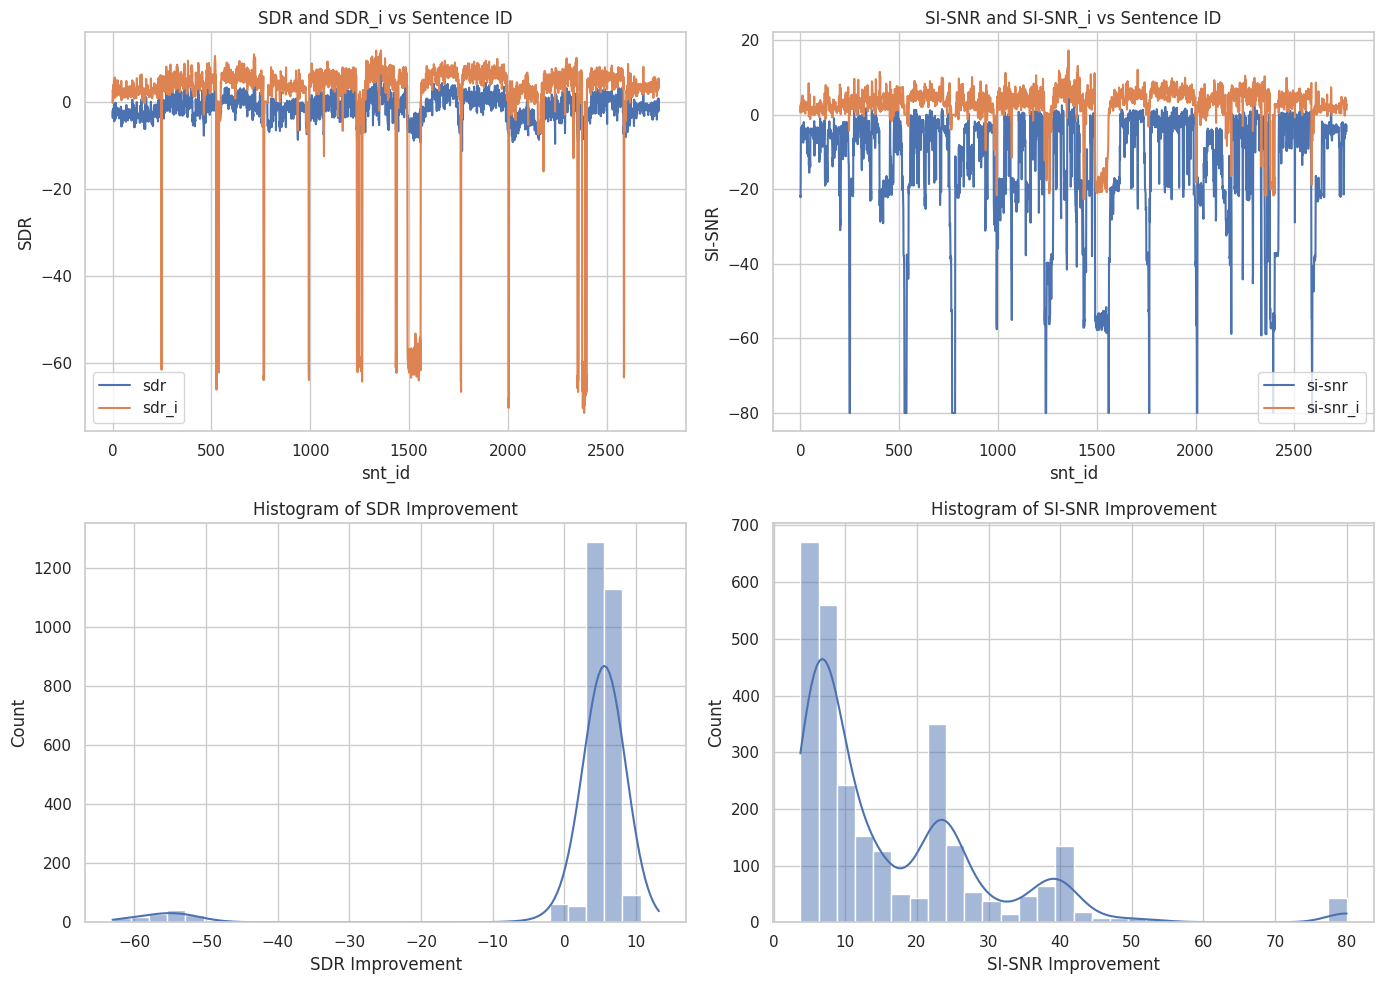

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set(style="whitegrid")

# Plot the metrics
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# SDR vs Snt ID
sns.lineplot(x="snt_id", y="sdr", data=df, ax=axs[0, 0], label="sdr")
sns.lineplot(x="snt_id", y="sdr_i", data=df, ax=axs[0, 0], label="sdr_i")
axs[0, 0].set_title("SDR and SDR_i vs Sentence ID")
axs[0, 0].set_ylabel("SDR")
axs[0, 0].legend()

# SI-SNR vs Snt ID
sns.lineplot(x="snt_id", y="si-snr", data=df, ax=axs[0, 1], label="si-snr")
sns.lineplot(x="snt_id", y="si-snr_i", data=df, ax=axs[0, 1], label="si-snr_i")
axs[0, 1].set_title("SI-SNR and SI-SNR_i vs Sentence ID")
axs[0, 1].set_ylabel("SI-SNR")
axs[0, 1].legend()

# Histogram of improvement in SDR
df["sdr_improvement"] = df["sdr_i"] - df["sdr"]
sns.histplot(df["sdr_improvement"], bins=30, kde=True, ax=axs[1, 0])
axs[1, 0].set_title("Histogram of SDR Improvement")
axs[1, 0].set_xlabel("SDR Improvement")

# Histogram of improvement in SI-SNR
df["si_snr_improvement"] = df["si-snr_i"] - df["si-snr"]
sns.histplot(df["si_snr_improvement"], bins=30, kde=True, ax=axs[1, 1])
axs[1, 1].set_title("Histogram of SI-SNR Improvement")
axs[1, 1].set_xlabel("SI-SNR Improvement")

plt.tight_layout()
plt.show()
